In [ ]:
pip install scikit-learn

In [ ]:
pip install seaborn

In [ ]:
%pip install matplotlib

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Lets Load the BOtson House Pricing Dataset

In [11]:

from sklearn.datasets import fetch_openml
boston = fetch_openml(name="Boston", version=1, as_frame=True)
df = boston.frame
df.head()
boston.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [ ]:
# Lets Check the Description of the dataset
print(boston.DESCR)

In [ ]:
print(boston.data)

In [ ]:
print(boston.target)

In [ ]:
print(boston.feature_names)

PREPARING THE DATASET

In [ ]:
dataset=pd.DataFrame(data=boston.data, columns=boston.feature_names)
dataset.head()

In [38]:
dataset['PRICE']=boston.target
dataset.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
dataset.info()

In [ ]:
### Summarizing the stats of the data
dataset.describe()

CHECKING THE MISSING VALUES

In [ ]:
dataset.isnull().sum()

EXPLORATORY DATA ANALYSIS[EDA]
CORRELATION

In [37]:
dataset.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993


In [ ]:
import seaborn as sns
sns.pairplot(dataset)

In [ ]:
plt.scatter(dataset['RM'], dataset['PRICE'])
plt.xlabel('RM')
plt.ylabel('PRICE')
#plt.title('Relationship between Crime Rate and House Price')
#plt.show()

In [ ]:
import seaborn as sns
sns.regplot(x="LSTAT", y="PRICE", data=dataset)

<Axes: xlabel='PTRATIO', ylabel='PRICE'>

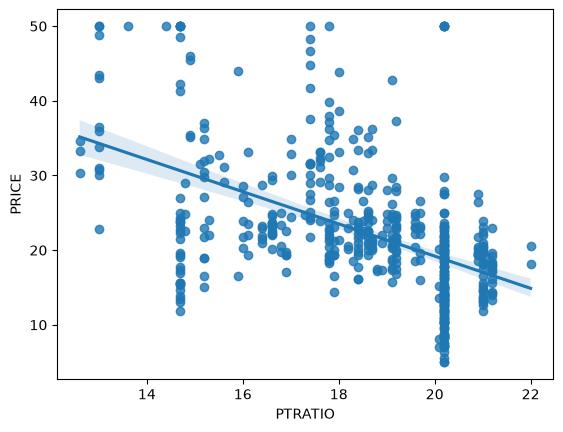

In [61]:
sns.regplot(x="PTRATIO", y="PRICE", data=dataset)

In [68]:
### INDEPENDENT AND DEPENDENT FEATURES
X = dataset.drop(columns=["PRICE"])
y = dataset["PRICE"]

In [69]:
X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,CHAS_num
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,0
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,0
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,0


In [70]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: PRICE, Length: 506, dtype: float64

In [76]:
### TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [77]:
x_test

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,CHAS_num
173,0.09178,0.0,4.05,0,0.510,6.416,84.1,2.6463,5,296.0,16.6,395.50,9.04,0
274,0.05644,40.0,6.41,1,0.447,6.758,32.9,4.0776,4,254.0,17.6,396.90,3.53,1
491,0.10574,0.0,27.74,0,0.609,5.983,98.8,1.8681,4,711.0,20.1,390.11,18.07,0
72,0.09164,0.0,10.81,0,0.413,6.065,7.8,5.2873,4,305.0,19.2,390.91,5.52,0
452,5.09017,0.0,18.10,0,0.713,6.297,91.8,2.3682,24,666.0,20.2,385.09,17.27,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,18.81100,0.0,18.10,0,0.597,4.628,100.0,1.5539,24,666.0,20.2,28.79,34.37,0
436,14.42080,0.0,18.10,0,0.740,6.461,93.3,2.0026,24,666.0,20.2,27.49,18.05,0
411,14.05070,0.0,18.10,0,0.597,6.657,100.0,1.5275,24,666.0,20.2,35.05,21.22,0
86,0.05188,0.0,4.49,0,0.449,6.015,45.1,4.4272,3,247.0,18.5,395.99,12.86,0


In [78]:
x_train

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,CHAS_num
477,15.02340,0.0,18.10,0,0.6140,5.304,97.3,2.1007,24,666.0,20.2,349.48,24.91,0
15,0.62739,0.0,8.14,0,0.5380,5.834,56.5,4.4986,4,307.0,21.0,395.62,8.47,0
332,0.03466,35.0,6.06,0,0.4379,6.031,23.3,6.6407,1,304.0,16.9,362.25,7.83,0
423,7.05042,0.0,18.10,0,0.6140,6.103,85.1,2.0218,24,666.0,20.2,2.52,23.29,0
19,0.72580,0.0,8.14,0,0.5380,5.727,69.5,3.7965,4,307.0,21.0,390.95,11.28,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.17120,0.0,8.56,0,0.5200,5.836,91.9,2.2110,5,384.0,20.9,395.67,18.66,0
270,0.29916,20.0,6.96,0,0.4640,5.856,42.1,4.4290,3,223.0,18.6,388.65,13.00,0
348,0.01501,80.0,2.01,0,0.4350,6.635,29.7,8.3440,4,280.0,17.0,390.94,5.99,0
435,11.16040,0.0,18.10,0,0.7400,6.629,94.6,2.1247,24,666.0,20.2,109.85,23.27,0


In [79]:
##STANDARDIZATION OF DATASET
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [80]:
x_train=scaler.fit_transform(x_train)

In [81]:
x_test=scaler.transform(x_test)

In [82]:
x_train

array([[ 1.28770177, -0.50032012,  1.03323679, ..., -0.07433689,
         1.75350503, -0.27808871],
       [-0.33638447, -0.50032012, -0.41315956, ...,  0.4301838 ,
        -0.5614742 , -0.27808871],
       [-0.40325332,  1.01327135, -0.71521823, ...,  0.06529747,
        -0.65159505, -0.27808871],
       ...,
       [-0.40547014,  2.95931752, -1.30336132, ...,  0.37901005,
        -0.91069248, -0.27808871],
       [ 0.85189733, -0.50032012,  1.03323679, ..., -2.69458597,
         1.52257036, -0.27808871],
       [-0.38135592, -0.50032012, -0.35216694, ..., -3.12158061,
        -0.25731635, -0.27808871]], shape=(404, 14))

MODEL TRAINING

In [ ]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(x_train, y_train)

In [ ]:
##  PRINT THE COEFFICIENTS OF THE MODEL
print(regression.coef_)

In [ ]:
print(regression.intercept_)

In [86]:
## ON WHICH PARAMETERS THE MODEL HAS BEEN TRAINED
print(regression.get_params())

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}


In [87]:
### PREDICTION WITH TEST DATA
reg_pred = regression.predict(x_test)

In [ ]:
reg_pred

In [ ]:
## PLOT A SCATTER PLOT FOR THE PREDICTION
plt.scatter(y_test, reg_pred)

In [ ]:
# RESIDUALS
residuals = y_test - reg_pred
residuals

In [ ]:
#PLOT THIS RESIDUALS
sns.histplot(residuals, kde=True)

In [ ]:
## SCATTERPLOT WITH RESPECT TO PREDICTION AND RESIDUALS
##UNIFORM DISTRIBUTION OF RESIDUALS
plt.scatter(reg_pred, residuals)

In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
print("MAE:", mean_absolute_error(y_test, reg_pred))
print("MSE:", mean_squared_error(y_test, reg_pred))
print(np.sqrt(mean_squared_error(y_test,reg_pred)))

MAE: 3.1890919658878487
MSE: 24.291119474973534
4.928602182665338


R SQUARE AND ADJUSTED R SQUARE
FORMULE FOR 
R SQUARE=1-SSR/SST
FORMULE FOR 
ADJUSTED R SQUARE=1-[(1-RSQUARE)(n-1)/(n-k-1)]



In [101]:
from sklearn.metrics import r2_score
score=r2_score(y_test, reg_pred)
print(score)

0.6687594935356318


In [102]:
1-(1-score)*(len(y_test)-1)/(len(y_test)-X.shape[1]-1)

0.6154564235298714

NEW DATA PREDICTION

In [112]:
X0 = boston.data.iloc[:, 0].values.reshape(-1, 1)

In [ ]:
X0

In [124]:
from sklearn.linear_model import LinearRegression

reg_single = LinearRegression()
reg_single.fit(boston.data.iloc[:, [0]], boston.target)
pred = reg_single.predict(boston.data.iloc[:, [0]])

In [130]:
single_scaler = StandardScaler()
single_scaler.fit(boston.data.iloc[:, [0]])
single_scaled = single_scaler.transform(boston.data.iloc[:, [0]])

In [ ]:
single_scaled

PICKLING THE MODEL FILE FOR DEPLOYMENT

In [132]:
import pickle

In [133]:
pickle.dump(regression,open('regmodedl.pkl','wb'))

In [145]:
pickled_model=pickle.load(open('regmodedl.pkl','rb'))

In [146]:
pickled_model.predict(scaler.transform(boston.data.iloc[:, [0]].values.reshape(-1, 1)))

c:\Users\saipo\OneDrive\Desktop\home credit\.venv313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: X has 1 features, but StandardScaler is expecting 14 features as input.